### Working on Oxford IIIT Pet Dataset for Class Assignment

## We can import the IIIT Pet Dataset from Pytorch's Torchvision as it is already built there for free Use

In [35]:
import torch
import numpy as np
import random

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


#### Use torchvision to import dataset because 

#### The torchvision package consists of popular datasets, model architectures, and common image transformations for computer vision.

In [36]:
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import v2    # Transforms are used to instatiate a transform , (Pass an input and get a transformed output)

In [37]:
data_transforms = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])     # Used to Transform the Input

### Loading the Dataset 

In [38]:
dataset = OxfordIIITPet(
    root='./data',
    split='trainval',
    target_types="category",
    transform=data_transforms,
    download=True
)

### Visualize the Dataset Randomly

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..1.8905451].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.605142].
C

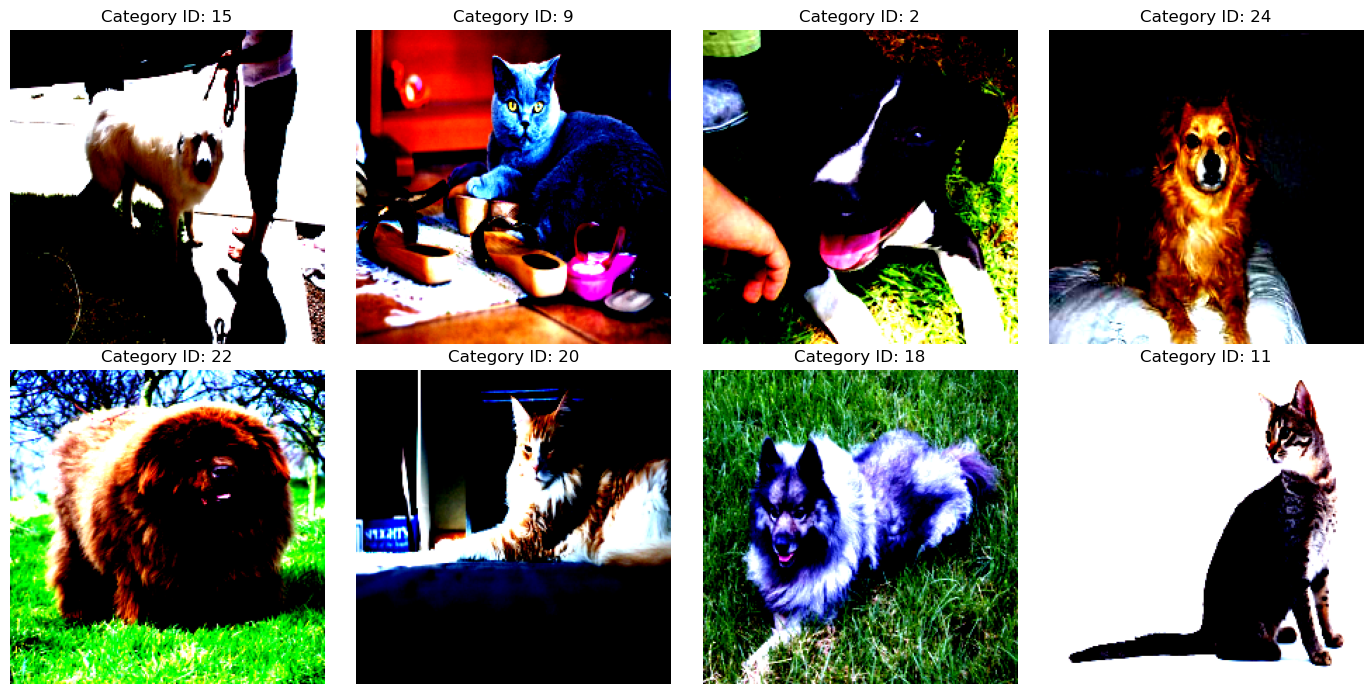

In [39]:
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2, 4, figsize=(14,7))

for ax in axes.flat:
    index = random.randint(0, len(dataset) - 1)
    image, label = dataset[index]

    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(F"Category ID: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()


### Creating a Train / Test / Validation Split

In [40]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset)- train_size

train_subset, val_subset = random_split(
    dataset, 
    [train_size, val_size],
    generator= torch.Generator().manual_seed(seed)
)

### Creating DataLoaders